<a href="https://colab.research.google.com/github/omshahu/ML_Practicals/blob/main/p5_Extra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Omprakash Shahu

UsnNo:CS23064

Lab 5 Extra Datasets

Aim:To implement the Random Forest algorithm on the Gaming and Mental Health dataset and evaluate the model performance using appropriate metrics.

In [30]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [31]:
from google.colab import drive
drive.mount('/content/drive')
path = "/content/drive/MyDrive/ML_Class/Gaming and Mental Health - Gaming and Mental Health.csv"
df = pd.read_csv(path)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,...,True,True,False,6.8,3.7,7,1.3,383.70,3,Severe
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,...,False,False,False,0.4,8.5,2,10.7,46.64,1,Low
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,...,True,False,True,1.8,7.1,5,3.2,100.81,6,Severe
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,...,False,True,True,0.2,5.2,4,9.1,51.60,7,High
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,...,False,False,False,0.5,6.1,4,4.5,32.57,1,Moderate


In [32]:
df.shape

(1000, 27)

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   record_id                         1000 non-null   object 
 1   age                               1000 non-null   int64  
 2   gender                            1000 non-null   object 
 3   daily_gaming_hours                1000 non-null   float64
 4   game_genre                        1000 non-null   object 
 5   primary_game                      1000 non-null   object 
 6   gaming_platform                   1000 non-null   object 
 7   sleep_hours                       1000 non-null   float64
 8   sleep_quality                     1000 non-null   object 
 9   sleep_disruption_frequency        1000 non-null   object 
 10  academic_work_performance         1000 non-null   object 
 11  grades_gpa                        754 non-null    float64
 12  work_pr

In [34]:
df.isnull().sum()

,0
record_id,0
age,0
gender,0
daily_gaming_hours,0
game_genre,0
primary_game,0
gaming_platform,0
sleep_hours,0
sleep_quality,0
sleep_disruption_frequency,0


In [35]:
df = df.dropna()

In [36]:
df.fillna(df.mean(numeric_only=True), inplace=True)

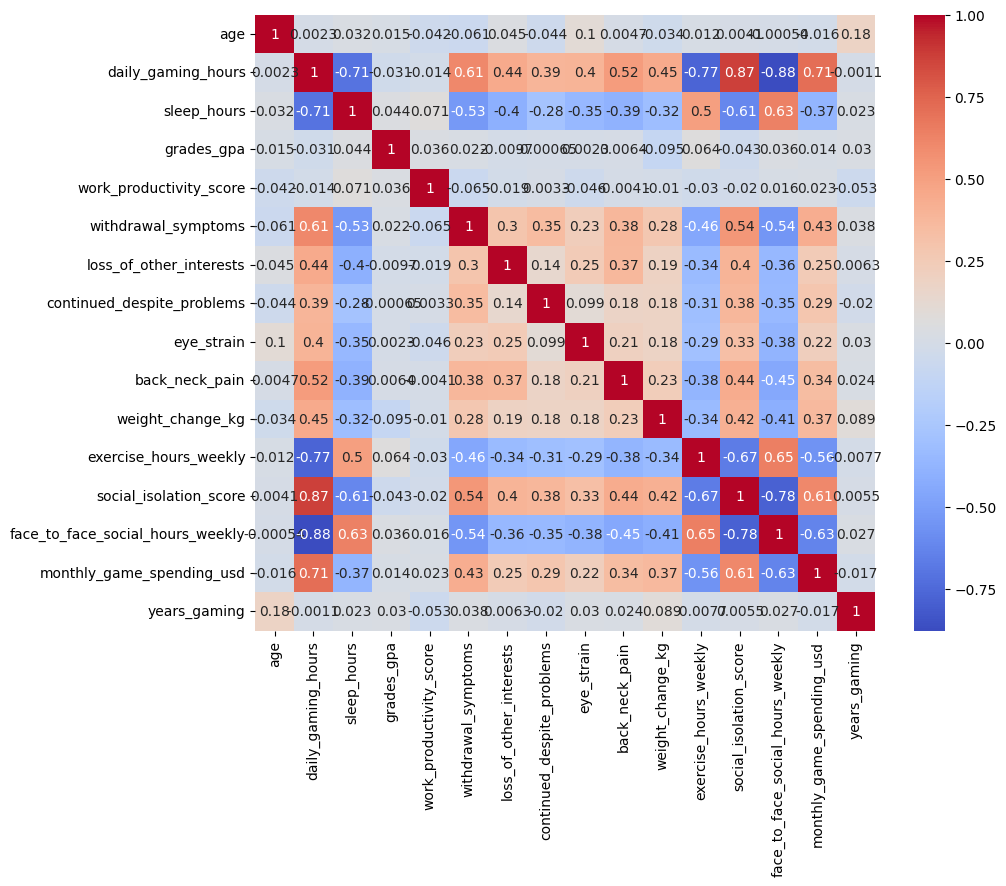

In [37]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [38]:
X = df.drop(columns=['gaming_addiction_risk_level'])   # change target name
y = df['gaming_addiction_risk_level']

In [39]:
X = pd.get_dummies(X, drop_first=True)

In [40]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [42]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.6395348837209303
              precision    recall  f1-score   support

        High       0.54      0.33      0.41        21
         Low       0.75      1.00      0.86        40
    Moderate       0.33      0.12      0.17        17
      Severe       0.43      0.75      0.55         8

    accuracy                           0.64        86
   macro avg       0.51      0.55      0.50        86
weighted avg       0.59      0.64      0.59        86



In [43]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9069767441860465


In [44]:
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.8255813953488372


In [45]:
from sklearn.neural_network import MLPClassifier
ann_model = MLPClassifier(hidden_layer_sizes=(50,50), max_iter=500)
ann_model.fit(X_train, y_train)
y_pred_ann = ann_model.predict(X_test)
print("ANN Accuracy:", accuracy_score(y_test, y_pred_ann))

ANN Accuracy: 0.5465116279069767


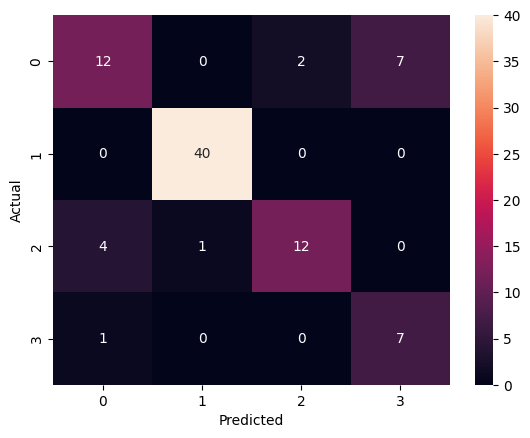

In [46]:
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [47]:
df = pd.read_csv(path)
df.head()

,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,...,True,True,False,6.8,3.7,7,1.3,383.70,3,Severe
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,...,False,False,False,0.4,8.5,2,10.7,46.64,1,Low
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,...,True,False,True,1.8,7.1,5,3.2,100.81,6,Severe
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,...,False,True,True,0.2,5.2,4,9.1,51.60,7,High
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,...,False,False,False,0.5,6.1,4,4.5,32.57,1,Moderate


In [48]:
df.columns

Index(['record_id', 'age', 'gender', 'daily_gaming_hours', 'game_genre',
       'primary_game', 'gaming_platform', 'sleep_hours', 'sleep_quality',
       'sleep_disruption_frequency', 'academic_work_performance', 'grades_gpa',
       'work_productivity_score', 'mood_state', 'mood_swing_frequency',
       'withdrawal_symptoms', 'loss_of_other_interests',
       'continued_despite_problems', 'eye_strain', 'back_neck_pain',
       'weight_change_kg', 'exercise_hours_weekly', 'social_isolation_score',
       'face_to_face_social_hours_weekly', 'monthly_game_spending_usd',
       'years_gaming', 'gaming_addiction_risk_level'],
      dtype='object')

In [49]:
X = df.drop(columns=['gaming_addiction_risk_level'])
y = df['gaming_addiction_risk_level']

In [50]:
X = pd.get_dummies(X, drop_first=True)

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [52]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [53]:
y_pred = model.predict(X_test)

In [54]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.85

Classification Report:

              precision    recall  f1-score   support

        High       0.78      0.66      0.71        38
         Low       0.97      0.93      0.95        99
    Moderate       0.70      0.79      0.74        33
      Severe       0.75      0.90      0.82        30

    accuracy                           0.85       200
   macro avg       0.80      0.82      0.81       200
weighted avg       0.86      0.85      0.85       200

